In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from all_funcs import *
from new_grad_descent import CustomGradiendDescent
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')

In [2]:
#загружаем датасет
df = pd.read_csv('podcasts.csv')

df_results = pd.read_excel('models_results.xlsx')

In [3]:
#удаляем все пропуски в данных
df = df.dropna(subset=['Listening_Time_minutes', 'Guest_Popularity_percentage', 'Episode_Length_minutes']).drop_duplicates()

In [4]:
#собираем кат и кол-ые фичи 
numeric_features = df.select_dtypes(np.number)
cat_col = df.select_dtypes(object).columns.to_list()
cat_col.append('Number_of_Ads')
cat_features = df[cat_col]
target_column = 'Listening_Time_minutes'

In [5]:
# формируем тестовую, тренировочную выборки
X, y = df.drop(labels=['Listening_Time_minutes'], axis=1), df['Listening_Time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Добавим к базовой линейной модели L1 регуляризацию, чтобы занулить ненужные признаки

In [9]:
param_regularization = {
    'model__alpha': np.logspace(-2, 3, 20)
}
model_lasso = make_pipeline_preprocessor_and_model(num_col=numeric_features.columns,
                                             cat_col=cat_col,
                                             model_class=Lasso)
grid_search_lasso = GridSearchCV(
    estimator=model_lasso,
    param_grid=param_regularization,
    cv=5,  # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Параллельные вычисления
    verbose=1,  # Уровень детализации
    return_train_score=True,
)

grid_search_lasso.fit(X_train, y_train)
print("Лучшие параметры:", grid_search_lasso.best_params_)
print("Лучшая оценка (mse):", grid_search_lasso.best_score_)

train_score = grid_search_lasso.score(X_train, y_train)
test_score = grid_search_lasso.score(X_test, y_test)
print(f"\nMSE на обучающей выборке: {train_score:.4f}")
print(f"MSE на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

cross_val_scores = cross_val_score(grid_search_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(cross_val_scores)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'model__alpha': np.float64(0.018329807108324356)}
Лучшая оценка (mse): -127.61838711982477

MSE на обучающей выборке: -127.3770
MSE на тестовой выборке: -126.1633
Разница (переобучение): -1.2137
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[-11.17036152 -11.35404756 -11.29395197 -11.30212693 -11.36612387]


In [14]:
#оценим точность метода путем разбиения данных, обучении модели и вычисления оценки 5 раз подряд в средней и медиане
print(f"Средняя - {cross_val_scores.mean()}")
print(f"Медиана - {np.median(cross_val_scores)}")


Средняя - -11.297322372442078
Медиана - -11.302126933340137


In [15]:
best_model = grid_search_lasso.best_estimator_
lasso_coef = best_model.named_steps['model'].coef_
feature_names = best_model[:-1].get_feature_names_out()
selected_features = feature_names[lasso_coef != 0]
print(f"Выбрано {len(selected_features)}")
print(selected_features)

Выбрано 22
['num__Episode_Length_minutes' 'num__Host_Popularity_percentage'
 'num__Guest_Popularity_percentage' 'num__Number_of_Ads'
 'cat__Podcast_Name_Healthy Living' 'cat__Podcast_Name_Lifestyle Lounge'
 'cat__Podcast_Name_Money Matters' 'cat__Podcast_Name_Sports Weekly'
 'cat__Genre_Comedy' 'cat__Genre_Health' 'cat__Genre_Music'
 'cat__Genre_News' 'cat__Genre_Sports' 'cat__Genre_Technology'
 'cat__Genre_True Crime' 'cat__Publication_Day_Monday'
 'cat__Publication_Day_Tuesday' 'cat__Publication_Day_Wednesday'
 'cat__Publication_Time_Morning' 'cat__Episode_Sentiment_Neutral'
 'cat__Episode_Sentiment_Positive' 'cat__Number_of_Ads_1']


In [16]:
y_pred = grid_search_lasso.predict(X_test)
y_pred_train = grid_search_lasso.predict(X_train)


Среднее остатков: -0.1658 (должно быть близко к 0)


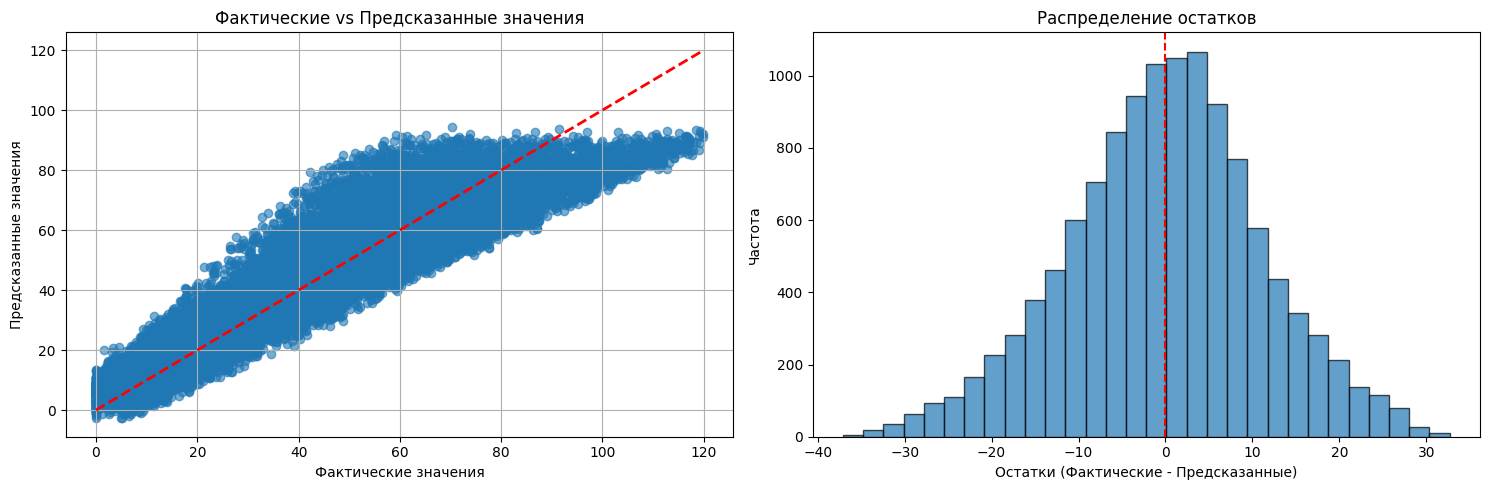

In [17]:
# Вычисляем остатки (ОПРЕДЕЛЯЕМ ПЕРЕМЕННУЮ residuals)
residuals = y_test - y_pred
print(f"\nСреднее остатков: {residuals.mean():.4f} (должно быть близко к 0)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Фактические vs Предсказанные значения
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Фактические vs Предсказанные значения')
axes[0].grid(True)

# 2. Распределение остатков
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (Фактические - Предсказанные)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

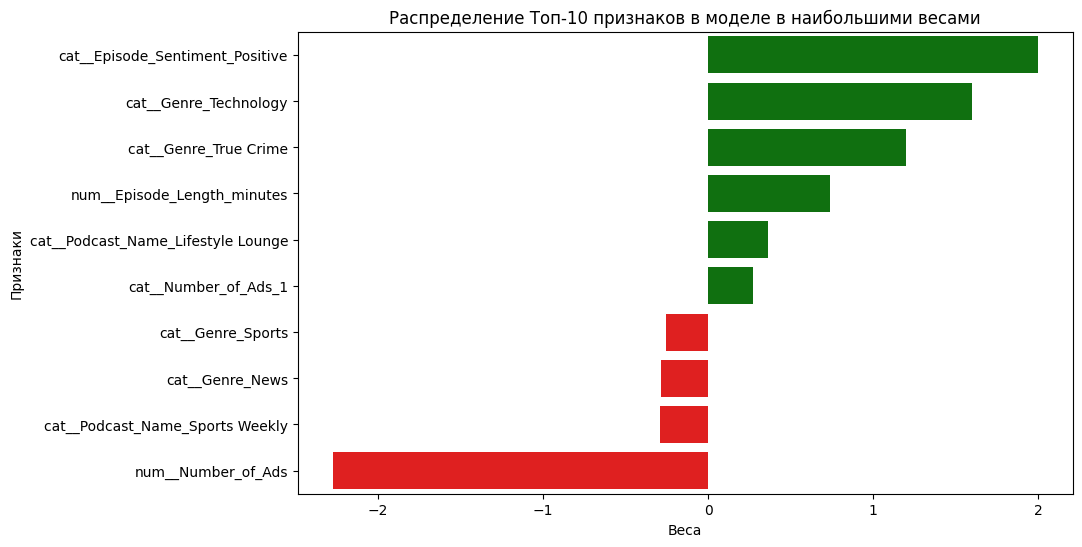

In [18]:
#Выведем наиболее важные признаки отобранные для предикта моделью
show_importance_feature_model(model=best_model, type_model='linear')

In [19]:
#Добавляем результат качества модели в итоговый датафрейм
append_model_results(data=df_results, y_pred=y_pred, y_pred_train=y_pred_train, y_test=y_test, y_train=y_train, title='linear_model_with_L1_regularization_and_best_params')

### Попробуем улучшить предсказания за счет кастомного градиентно спуска и L1 регуляризации 

In [21]:
#Определеяем списки гиперпараметров для градиентного спуска
params_grad = {
    'model__loss': ['mse'],
    'model__learning_rate': [0.1, 0.01, 0.001, 0.0001, 0.0009],
    'model__n_iters': [100, 500, 1000]
}

In [22]:
#Определеяем гиперпараметры для линейной модели с L1-регуляризациtq
params_linear_model = {
    'penalty': ['l1'],
    'alpha' : grid_search_lasso.best_params_
}

In [27]:
#Формируем пайплайн модель с помощью кастомной функции
model_gradient_scale = make_pipeline_preprocessor_and_model(num_col=numeric_features.columns, cat_col=cat_col, model_class=CustomGradiendDescent, scaler=True, params=params_linear_model)

#Формируем сетку для подбора лучших параметнов градиентного спуска
grid_search_for_custom_gd_with_regulariation = GridSearchCV (
    estimator=model_gradient_scale,
    param_grid=params_grad,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)

Подбираем по сетке лучшие параметры для градиентного спуска

In [28]:
grid_search_for_custom_gd_with_regulariation.fit(X_train, y_train)

,estimator,Pipeline(step...lty=['l1']))])
,param_grid,"{'model__learning_rate': [0.1, 0.01, ...], 'model__loss': ['mse'], 'model__n_iters': [100, 500, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [29]:
#Делаем предикты на тесте и трейне для оценки качества модели, а также для выявления ПЕРЕОБУЧЕНИЯ
y_pred = grid_search_for_custom_gd_with_regulariation.predict(X_test)
y_pred_train = grid_search_for_custom_gd_with_regulariation.predict(X_train)
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='TEST')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='TRAIN')

=============================TEST========================================
R2 - 0.8272194513224793
MSE - 126.8829353204548
RMSE - 11.264232566866454
=============================TRAIN========================================
R2 - 0.8285484248034054
MSE - 126.80622173830692
RMSE - 11.260826867433266


In [30]:
#Добавляем  модель с метриками качества в итоговый датафрейм
append_model_results(data=df_results, y_pred=y_pred, y_pred_train=y_pred_train, y_test=y_test, y_train=y_train, title='linear_model_with_L1_regularization_and_custom_gradient_descent')

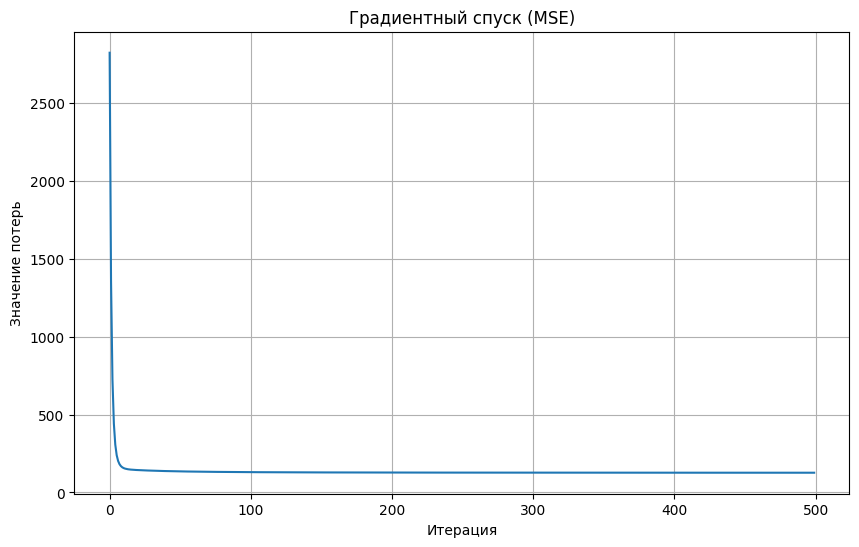

Лучшие параметры: {'model__learning_rate': 0.1, 'model__loss': 'mse', 'model__n_iters': 500}
Лучшая оценка MSE: -128.20973220730144

MSE на обучающей выборке: -126.8062
MSE на тестовой выборке: -126.8829
Разница (переобучение): 0.0767


In [31]:
#Выведем график обучения градиентного спуска
grid_search_for_custom_gd_with_regulariation.best_estimator_['model'].plot_loss()

print("Лучшие параметры:", grid_search_for_custom_gd_with_regulariation.best_params_)
print("Лучшая оценка MSE:", grid_search_for_custom_gd_with_regulariation.best_score_)

train_score = grid_search_for_custom_gd_with_regulariation.score(X_train, y_train)
test_score = grid_search_for_custom_gd_with_regulariation.score(X_test, y_test)
print(f"\nMSE на обучающей выборке: {train_score:.4f}")
print(f"MSE на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

Градиентый спуск  выходит на плато уже к первой сотне итераций. Посмотрим устойчивость модели с помощью кросс-валидации

In [32]:
score = cross_val_score(grid_search_for_custom_gd_with_regulariation.best_estimator_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(score)

[-11.19479968 -11.38275443 -11.32375383 -11.30248602 -11.40983924]


In [33]:
#оценим точность метода путем разбиения данных, обучении модели и вычисления оценки 5 раз подряд в средней и медиане
print(f"Средняя - {score.mean()}")
print(f"Медиана - {np.median(score)}")


Средняя - -11.322726642037873
Медиана - -11.323753831038545


### Модель стабильна, разброс на всех фолдах минимальный, но качество не улучшается. 

### Обучим случайный лес c подобранными гиперпараметрами на урезанном по "ненужным" фичам датасете

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

Сформируем пайплайн для предобработки данных

In [35]:
#формируем фичи для пайплайна
numeric_features_col = numeric_features.columns[:-1]
cat_pipe = Pipeline([('ohe', OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False))])
num_pipe = Pipeline([('scaler', StandardScaler())])

preprocessing = ColumnTransformer([('num', num_pipe, numeric_features_col),
                                   ('cat', cat_pipe, cat_features.columns)])

#Создаем иперпараметров для подбора сетке
param_grid_tree = {
    'model__n_estimators': [30, 50, 70, 90],
    # 'model__max_depth':  [3, 5, 10, 20, 50, 90],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt'],
    'model__bootstrap': [True]
}

#Формируем итоговый пайплайн
random_pipe_model = Pipeline([
    ('preproc', preprocessing),
    ('feature_selection', SelectFromModel(RandomForestRegressor(n_estimators=50))),
    ('model', RandomForestRegressor())
])

In [37]:
#Формируем сетку подбора гиперпараметров с кросс-валидацией для обучения random forest
tree_grid_search_ = GridSearchCV(
    estimator=random_pipe_model,
    param_grid=param_grid_tree,
    cv=3,  # 3-кратная кросс-валидация
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Параллельные вычисления
    verbose=1,  # Уровень детализации
    return_train_score=True,
)

In [38]:
#Обучаем модель по подбору гиперпараметров
tree_grid_search_.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__bootstrap': [True], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [39]:
#Делаем предикты на тесте и трейне для оценки качества модели, а также для выявления ПЕРЕОБУЧЕНИЯ
y_pred = tree_grid_search_.best_estimator_.predict(X_test)
y_pred_train = tree_grid_search_.best_estimator_.predict(X_train)
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='TEST')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='TRAIN')

=============================TEST========================================
R2 - 0.8223598043351825
MSE - 130.45166038290537
RMSE - 11.421543695267527
=============================TRAIN========================================
R2 - 0.9068798213011701
MSE - 68.87202998779529
RMSE - 8.298917398540324



Среднее остатков: -0.1464 (должно быть близко к 0)


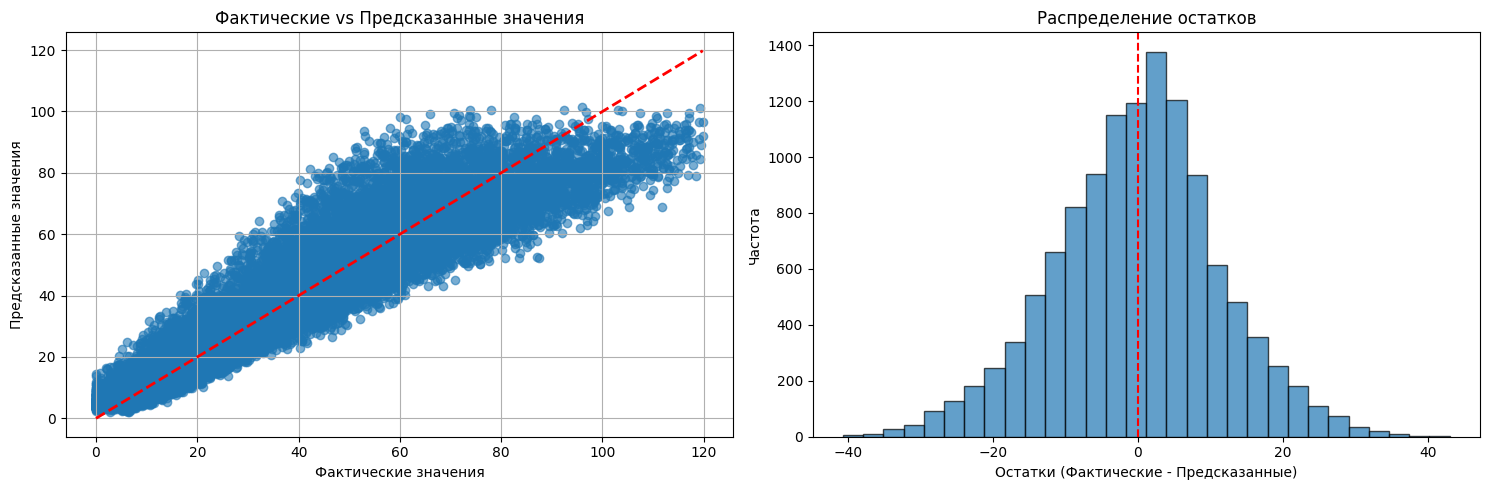

In [40]:
# Вычисляем остатки (ОПРЕДЕЛЯЕМ ПЕРЕМЕННУЮ residuals)
residuals = y_test - y_pred
print(f"\nСреднее остатков: {residuals.mean():.4f} (должно быть близко к 0)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Фактические vs Предсказанные значения
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Фактические vs Предсказанные значения')
axes[0].grid(True)

# 2. Распределение остатков
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (Фактические - Предсказанные)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

In [41]:
#Добавляем  модель с метриками качества в итоговый датафрейм

append_model_results(data=df_results, y_pred=y_pred, y_pred_train=y_pred_train, y_test=y_test, y_train=y_train, title='random_forest_with_best_params')

In [46]:
#Выводим лучшие параметры и гиперпараметры подобранные по сетке
print("Лучшие параметры:", tree_grid_search_.best_params_)
print("Лучшая оценка (MSE):", tree_grid_search_.best_score_)


#Выводим метрики лучшей модели подобранной по сетке
train_score = tree_grid_search_.best_estimator_.score(X_train, y_train)
test_score = tree_grid_search_.best_estimator_.score(X_test, y_test)
print(f"\nR2 на обучающей выборке: {train_score:.4f}")
print(f"R2 на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

Лучшие параметры: {'model__bootstrap': True, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 90}
Лучшая оценка (MSE): -131.73976331129285

R2 на обучающей выборке: 0.9069
R2 на тестовой выборке: 0.8224
Разница (переобучение): 0.0845


In [43]:
#оценим точность метода путем разбиения данных, обучении модели и вычисления оценки 5 раз подряд в средней и медиане
cross_val_scores= cross_val_score(tree_grid_search_.best_estimator_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print(f"Средняя - {cross_val_scores.mean()}")
print(f"Медиана - {np.median(cross_val_scores)}")


Средняя - -11.457259707591266
Медиана - -11.469549254424019


In [44]:
#какие фичи были выбраны в Random Forest
feature_selector = tree_grid_search_.best_estimator_.named_steps['feature_selection']
selected_mask = feature_selector.get_support()
preprocessor = tree_grid_search_.best_estimator_.named_steps['preproc']
feature_names = preprocessor.get_feature_names_out()
selected_feature_names = feature_names[selected_mask].tolist()
selected_feature_names

['num__Episode_Length_minutes',
 'num__Host_Popularity_percentage',
 'num__Guest_Popularity_percentage',
 'num__Number_of_Ads']

### Итоговые результаты

In [56]:
df_results.head()

,model,train_r2,train_mse,train_rmse,test_r2,test_mse,test_rmse
0,base_linear_model,0.827923,127.096726,11.273718,0.828215,127.374725,11.286041
1,linear_model_with_L1_regularization_and_best_p...,0.827777,127.376991,11.286142,0.828199,126.163301,11.232244
2,linear_model_with_L1_regularization_and_custom...,0.828548,126.806222,11.260827,0.827219,126.882935,11.264233
3,random_forest_with_best_params,0.906880,68.872030,8.298917,0.822360,130.451660,11.421544


##### Лучшее качество показала линейная модель с L1-регуляризацией и подобранными гиперпараметрами

Приложение модели к чему?

## Тестовый предикт на рандомных данных 

In [ ]:
test_sample = {
    'Podcast_Name' : 'Market Masters',
    'Episode_Title': 'Episode 83',
    'Episode_Length_minutes' : 55.8,
    'Genre': 'Lifestyle',
    'Host_Popularity_percentage': 56.01,
    'Publication_Day': 'Friday',
    'Publication_Time': 'Night',
    'Guest_Popularity_percentage': 25.1,
    'Number_of_Ads': 1,
    'Episode_Sentiment': 'Positive'
}

In [ ]:
df_test = pd.DataFrame(test_sample, index=[1])

In [ ]:
df_tests

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
1,Market Masters,Episode 83,55.8,Lifestyle,56.01,Friday,Night,25.1,1,Positive


In [ ]:
tree_grid_search_.best_estimator_.predict(df_test)

array([42.7823561])

In [ ]:
tree_grid_search_.best_estimator_.feature_names_in_


array(['Podcast_Name', 'Episode_Title', 'Episode_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment'], dtype=object)